# Qiskit CNOT count plots

Use this notebook to inspect CNOT counts saved by `src.plotting.qiskit_plot`. Change `DATA_FILE` in the next cell to choose a different JSON file from the `results/` folder.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

DATA_FILE = "qiskit_cnot_vs_d_150_16_07_trotter10.json"


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results").is_dir() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("Could not find the bosonic_gatecounts project root.")


project_root = find_project_root(Path.cwd().resolve())
results_path = project_root / "results" / DATA_FILE

with open(results_path) as f:
    results = json.load(f)

print(f"Loaded {results_path}")


Loaded /Users/hollyelizabethmitchell/Documents/code/bosonic_gatecounts/results/qiskit_cnot_vs_d_150_16_07_trotter10.json


## Plot settings

In [3]:
colors = {
    "sb": "blue",
    "gray": "orange",
    "unary": "green",
}

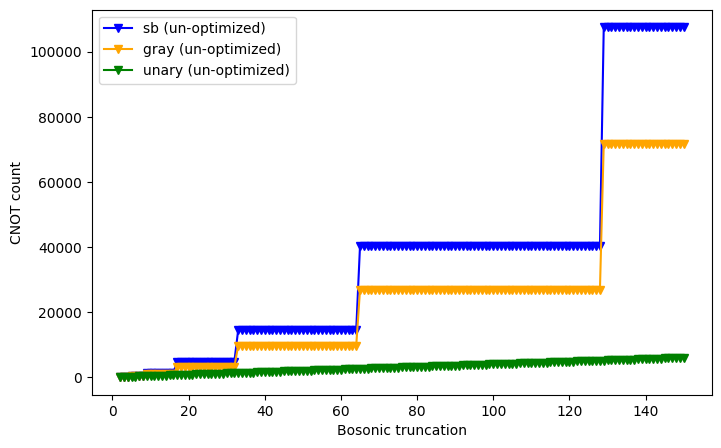

In [4]:
# plot of the unoptimized cnot counts

plt.figure(figsize=(8, 5))

for encoding, (ds, raw, opt) in results.items():
    color = colors.get(encoding, None)
    plt.plot(ds, raw, marker="v", color=color, label=f"{encoding} (un-optimized)")

plt.xlabel("Bosonic truncation")
plt.ylabel("CNOT count")
plt.legend()
plt.show()

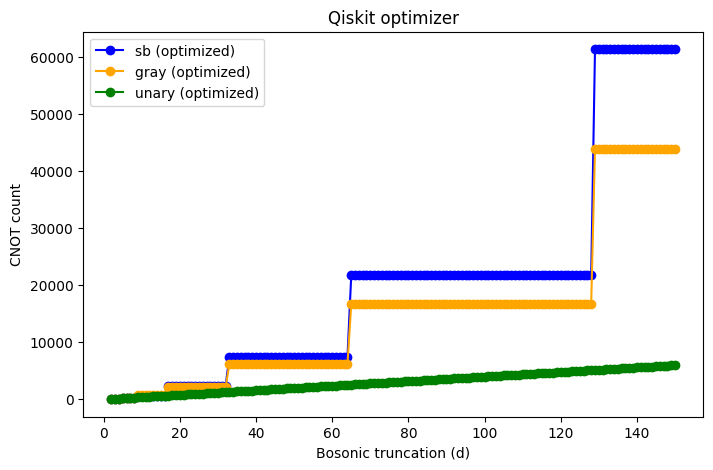

In [5]:
# optimized cnot counts

plt.figure(figsize=(8, 5))

for encoding, (ds, raw, opt) in results.items():
    color = colors.get(encoding, None)
    plt.plot(ds, opt, marker="o", color=color, label=f"{encoding} (optimized)")

plt.xlabel("Bosonic truncation (d)")
plt.ylabel("CNOT count")
plt.title("Qiskit optimizer")
plt.legend()
plt.show()

In [6]:
# Getting CNOT counts for classical max out

target_d = 128

for encoding in ["sb", "gray", "unary"]:
    ds, raw_counts, optimized_counts = results[encoding]

    index = ds.index(target_d)

    print(
        f"{encoding}: "
        f"raw CNOTs = {raw_counts[index]}, "
        f"optimized CNOTs = {optimized_counts[index]}"
    )


sb: raw CNOTs = 40320, optimized CNOTs = 21741
gray: raw CNOTs = 26880, optimized CNOTs = 16740
unary: raw CNOTs = 5080, optimized CNOTs = 5080


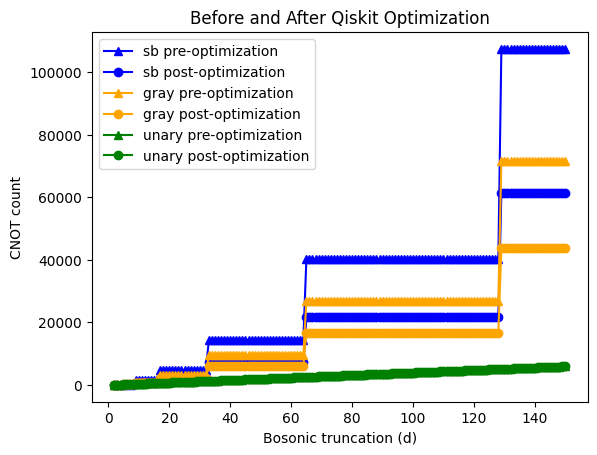

In [ ]:
# Both on the same plot

plt.figure(figsize=(8, 5))

for encoding, (ds, raw, opt) in results.items():
    color = colors.get(encoding, None)

    plt.plot(
        ds,
        raw,
        marker="^",
        color=color,
        label=f"{encoding} pre-optimization",
    )

    plt.plot(
        ds,
        opt,
        marker="o",
        color=color,
        label=f"{encoding} post-optimization",
    )

plt.xlabel("Bosonic truncation (d)")
plt.title("Before and After Qiskit Optimization")
plt.ylabel("CNOT count")
plt.legend()
plt.show()